In [14]:
import json
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

In [15]:
m3cot_ivtlr = Path("/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/output/inference/m3cot")
sqa_ivtlr = Path("/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/output/inference/sqa")

baseline = Path("/home/csalt/Haider/DVLM/lvar/outputs/baseline_and_pooling_results")

m3cot_baseline = Path("/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/output/inference/m3cot_base")
sqa_baseline = Path("/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/output/inference/sqa_base")

m3cot_ivtlr_no_vis = Path("/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/output/inference/m3cot_no_vis")
sqa_ivtlr_no_vis = Path("/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/output/inference/sqa_no_vis")

In [16]:
def _parse_final_line(log_path: Path):
    if not log_path or not log_path.exists():
        return None
    final_pattern = re.compile(
        r"\[FINAL\]\s*Total:\s*(\d+),\s*Correct:\s*(\d+),\s*Accuracy:\s*([0-9.]+)%"
    )
    # Read last 200 lines to capture the final summary without loading huge logs.
    try:
        lines = log_path.read_text(encoding="utf-8", errors="ignore").splitlines()
    except OSError:
        return None
    for line in reversed(lines[-200:]):
        match = final_pattern.search(line)
        if match:
            total = int(match.group(1))
            correct = int(match.group(2))
            acc = float(match.group(3))
            return {"total": total, "correct": correct, "accuracy": acc}
    return None


def _pick_log(epoch_dir: Path, pattern: str):
    matches = sorted(epoch_dir.glob(pattern))
    if matches:
        return matches[0]
    # Fallback: any stdout/stderr log file in the folder.
    fallback = sorted(epoch_dir.glob("*stdout*stderr*.log"))
    return fallback[0] if fallback else None


def _format_cell(metrics):
    if not metrics:
        return ""
    return f"{metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.2f}%)"


In [17]:
rows = []


def _append_epoch_rows(root_dir: Path, pattern: str, dataset_key: str, prefix: str):
    for epoch_dir in sorted(root_dir.glob("*")):
        # print(f"Processing {epoch_dir} for dataset {dataset_key} with prefix {prefix}")
        log_path = _pick_log(epoch_dir, pattern)
        metrics = _parse_final_line(log_path)
        rows.append({
            "Model Type": f"{prefix}_{epoch_dir.name}",
            "m3cot": metrics if dataset_key == "m3cot" else None,
            "scienceqa": metrics if dataset_key == "scienceqa" else None,
            "clevr": None,
        })


_append_epoch_rows(m3cot_ivtlr, "*m3cot*stdout*stderr*.log", "m3cot", "ivtlr")
_append_epoch_rows(sqa_ivtlr, "*sqa*stdout*stderr*.log", "scienceqa", "ivtlr")

_append_epoch_rows(m3cot_baseline, "*m3cot*stdout*stderr*.log", "m3cot", "baseline")
_append_epoch_rows(sqa_baseline, "*sqa*stdout*stderr*.log", "scienceqa", "baseline")

_append_epoch_rows(m3cot_ivtlr_no_vis, "*m3cot*stdout*stderr*.log", "m3cot", "ivtlr_no_vis")
_append_epoch_rows(sqa_ivtlr_no_vis, "*sqa*stdout*stderr*.log", "scienceqa", "ivtlr_no_vis")

# Merge rows by epoch name so both datasets land on the same row.
merged = {}
for row in rows:
    key = row["Model Type"]
    merged.setdefault(key, {"Model Type": key, "m3cot": None, "scienceqa": None, "clevr": None})
    for col in ["m3cot", "scienceqa", "clevr"]:
        if row[col] is not None:
            merged[key][col] = row[col]


def _epoch_sort_key(name):
    try:
        return int(name.split("_")[-1])
    except ValueError:
        return 0


ivtlr_rows = [
    merged[k]
    for k in sorted(
        [k for k in merged.keys() if k.startswith("ivtlr_")],
        key=_epoch_sort_key,
    )
]

baseline_epoch_rows = [
    merged[k]
    for k in sorted(
        [k for k in merged.keys() if k.startswith("baseline_epoch_")],
        key=_epoch_sort_key,
    )
]

rows = ivtlr_rows + baseline_epoch_rows

baseline_files = sorted(baseline.glob("*pooling_predictions_summary.json"))
baseline_rows = {}
for summary_path in baseline_files:
    with summary_path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    metrics = data.get("metrics", {})
    dataset_name = summary_path.name.replace("_pooling_predictions_summary.json", "")
    for key in [
        "full_image",
        "mean_pooled",
        "max_pooled",
        "region_mean_pooled",
        "region_max_pooled",
    ]:
        entry = metrics.get(key)
        if not entry:
            continue
        row_name = f"baseline_{key}"
        row = baseline_rows.setdefault(
            row_name,
            {"Model Type": row_name, "m3cot": None, "scienceqa": None, "clevr": None},
        )
        normalized = {
            "correct": entry.get("correct"),
            "total": entry.get("total"),
            "accuracy": entry.get("accuracy", 0.0) * 100.0,
        }
        if dataset_name == "m3cot":
            row["m3cot"] = normalized
        elif dataset_name in {"scienceqa", "sqa"}:
            row["scienceqa"] = normalized
        elif dataset_name == "clevr":
            row["clevr"] = normalized

rows.extend([baseline_rows[k] for k in sorted(baseline_rows.keys())])

In [18]:
def _metric_to_count(metrics):
    if not metrics:
        return ""
    return f"{metrics['correct']}/{metrics['total']}"


def _metric_to_accuracy(metrics):
    if not metrics:
        return ""
    return f"{metrics['accuracy']:.2f}%"


def _metric_to_both(metrics):
    if not metrics:
        return ""
    return f"{metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.2f}%)"


def _render_df(raw_rows, value_fn):
    rendered = []
    for raw in raw_rows:
        rendered.append(
            {
                "Model Type": raw["Model Type"],
                "m3cot": value_fn(raw.get("m3cot")),
                "scienceqa": value_fn(raw.get("scienceqa")),
                "clevr": value_fn(raw.get("clevr")),
            }
        )
    return pd.DataFrame(rendered).set_index("Model Type")


column_map = {
    "m3cot": "M3Cot",
    "scienceqa": "ScienceQA",
    "clevr": "Clevr",
}


baseline_map = {
    "baseline_full_image": "Baseline (Full Image)",
    "baseline_mean_pooled": "Baseline (Mean Pooled)",
    "baseline_max_pooled": "Baseline (Max Pooled)",
    "baseline_region_mean_pooled": "Baseline (Region Mean Pooled)",
    "baseline_region_max_pooled": "Baseline (Region Max Pooled)",
}


def _apply_labels(df):
    def _label(name):
        if name.startswith("ivtlr_epoch_"):
            return name.replace("ivtlr_epoch_", "IVTLR Epoch ")
        if name.startswith("baseline_epoch_"):
            return name.replace("baseline_epoch_", "Baseline Epoch ")
        if name.startswith("ivtlr_no_visual"):
            return "IVTLR (No Visual)"
        if name.startswith("ivtlr_no_vis_epoch_"):
            return name.replace("ivtlr_no_vis_epoch_", "IVTLR (No Vis Train) Epoch ")
        if name.startswith("ivtlr_no_reasoning"):
            return "IVTLR (No Reasoning)"
        return baseline_map.get(
            name,
            name.replace("epoch_", "Epoch ") if name.startswith("epoch_") else name,
        )

    df = df.rename(columns=column_map)
    df.index = df.index.map(_label)
    return df


def _reorder_table(df):
    desired_order = [
        "IVTLR (No Visual)",
        "IVTLR (No Vis Train) Epoch 16",
    ]
    existing = [name for name in desired_order if name in df.index]
    remaining = [name for name in df.index if name not in existing]
    return df.loc[existing + remaining]


table_both = _reorder_table(_apply_labels(_render_df(rows, _metric_to_both)))
table_counts = _reorder_table(_apply_labels(_render_df(rows, _metric_to_count)))
table_accuracy = _reorder_table(_apply_labels(_render_df(rows, _metric_to_accuracy)))

In [21]:
display(table_accuracy.loc[["IVTLR (No Visual)", "IVTLR (No Vis Train) Epoch 16", "IVTLR (No Reasoning)", "IVTLR Epoch 16", "Baseline Epoch 16", "Baseline (Full Image)"]][["M3Cot", "ScienceQA"]])

,M3Cot,ScienceQA
Model Type,,
IVTLR (No Visual),64.88%,92.12%
IVTLR (No Vis Train) Epoch 16,64.88%,92.12%
IVTLR (No Reasoning),64.62%,92.17%
IVTLR Epoch 16,64.75%,92.27%
Baseline Epoch 16,51.60%,83.69%
Baseline (Full Image),43.01%,76.90%


In [22]:
display(table_accuracy)
display(table_counts)
display(table_both)

,M3Cot,ScienceQA,Clevr
Model Type,,,
IVTLR (No Visual),64.88%,92.12%,
IVTLR (No Vis Train) Epoch 16,64.88%,92.12%,
IVTLR (No Reasoning),64.62%,92.17%,
IVTLR Epoch 4,33.61%,46.21%,
IVTLR Epoch 8,56.04%,79.33%,
IVTLR Epoch 12,55.95%,86.66%,
IVTLR Epoch 16,64.75%,92.27%,
Baseline Epoch 4,48.19%,79.82%,
Baseline Epoch 8,51.68%,81.66%,


,M3Cot,ScienceQA,Clevr
Model Type,,,
IVTLR (No Visual),1504/2318,1858/2017,
IVTLR (No Vis Train) Epoch 16,1504/2318,1858/2017,
IVTLR (No Reasoning),1498/2318,1859/2017,
IVTLR Epoch 4,779/2318,932/2017,
IVTLR Epoch 8,1299/2318,1600/2017,
IVTLR Epoch 12,1297/2318,1748/2017,
IVTLR Epoch 16,1501/2318,1861/2017,
Baseline Epoch 4,1117/2318,1610/2017,
Baseline Epoch 8,1198/2318,1647/2017,


,M3Cot,ScienceQA,Clevr
Model Type,,,
IVTLR (No Visual),1504/2318 (64.88%),1858/2017 (92.12%),
IVTLR (No Vis Train) Epoch 16,1504/2318 (64.88%),1858/2017 (92.12%),
IVTLR (No Reasoning),1498/2318 (64.62%),1859/2017 (92.17%),
IVTLR Epoch 4,779/2318 (33.61%),932/2017 (46.21%),
IVTLR Epoch 8,1299/2318 (56.04%),1600/2017 (79.33%),
IVTLR Epoch 12,1297/2318 (55.95%),1748/2017 (86.66%),
IVTLR Epoch 16,1501/2318 (64.75%),1861/2017 (92.27%),
Baseline Epoch 4,1117/2318 (48.19%),1610/2017 (79.82%),
Baseline Epoch 8,1198/2318 (51.68%),1647/2017 (81.66%),


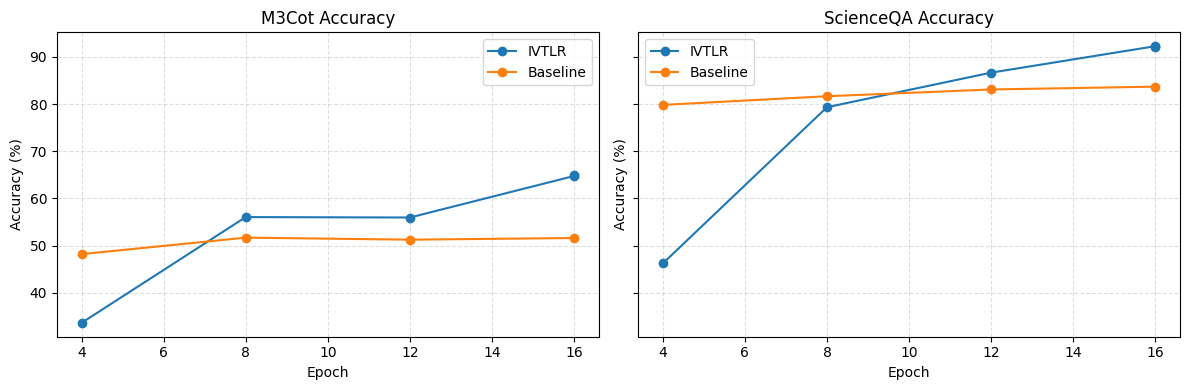

In [23]:
def _epoch_number(name):
    try:
        return int(name.split("_")[-1])
    except ValueError:
        return None


def _series_from_rows(epoch_rows, dataset_key):
    points = []
    for row in epoch_rows:
        epoch = _epoch_number(row["Model Type"])
        metrics = row.get(dataset_key)
        if epoch is None or not metrics:
            continue
        points.append((epoch, metrics["accuracy"]))
    return sorted(points, key=lambda x: x[0])


def _plot_progress(ax, dataset_label, dataset_key):
    ivtlr_points = _series_from_rows(ivtlr_rows, dataset_key)
    baseline_points = _series_from_rows(baseline_epoch_rows, dataset_key)

    if ivtlr_points:
        x, y = zip(*ivtlr_points)
        ax.plot(x, y, marker="o", label="IVTLR")
    if baseline_points:
        x, y = zip(*baseline_points)
        ax.plot(x, y, marker="o", label="Baseline")

    ax.set_title(f"{dataset_label} Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
_plot_progress(axes[0], "M3Cot", "m3cot")
_plot_progress(axes[1], "ScienceQA", "scienceqa")
plt.tight_layout()
plt.show()

In [24]:
m3cot_ivtlr_train = Path("/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/output/qwen_IVTLR_m3cot/qwenvl_m3cot.log")
sqa_ivtlr_train = Path("/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/output/qwen_IVTLR_sqa/qwenvl_scienceqa.log")

m3cot_base_train = Path("/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/output/qwen_IVTLR_m3cot_base/qwenvl_m3cot_base.log")
sqa_base_train = Path("/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/output/qwen_IVTLR_sqa_base/qwenvl_scienceqa_base.log")

m3cot_no_vis_train = Path("/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/output/qwen_IVTLR_m3cot_no_vis/qwenvl_m3cot_no_vis.log")
sqa_no_vis_train = Path("/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/output/qwen_IVTLR_sqa_no_vis/qwenvl_scienceqa_no_vis.log")

In [25]:
logs_dict = {"M3CoT": {
        "IVTLR": m3cot_ivtlr_train,
        "Base": m3cot_base_train,
        "(No Visual)": m3cot_no_vis_train,
    },
    "ScienceQA": {
        "IVTLR": sqa_ivtlr_train,
        "Base": sqa_base_train,
        "(No Visual)": sqa_no_vis_train,
    },
}

epoch_loss_pattern = re.compile(r"Training Epoch:\s*(\d+)/(\d+),.*?\(loss:\s*([0-9.]+)")
# print(logs_dict.items())
rows = []
for dataset_name, models in logs_dict.items():
    for model_name, log_path in models.items():
        if not log_path or not log_path.exists():
            continue
        # print(model_name, log_path)
        epoch_losses = defaultdict(list)
        for line in log_path.read_text(encoding="utf-8", errors="ignore").splitlines():
            match = epoch_loss_pattern.search(line)
            if not match:
                continue
            epoch = int(match.group(1))
            loss = float(match.group(3))
            epoch_losses[epoch].append(loss)
        for epoch in sorted(epoch_losses.keys()):
            losses = epoch_losses[epoch]
            avg_loss = sum(losses) / len(losses)
            rows.append({
                "dataset": dataset_name,
                "model": model_name,
                "epoch": epoch,
                "steps": len(losses),
                "avg_loss": avg_loss,
            })

loss_df = pd.DataFrame(rows)
if not loss_df.empty:
    loss_df = loss_df.sort_values(["dataset", "model", "epoch"]).set_index(["dataset", "model", "epoch"])

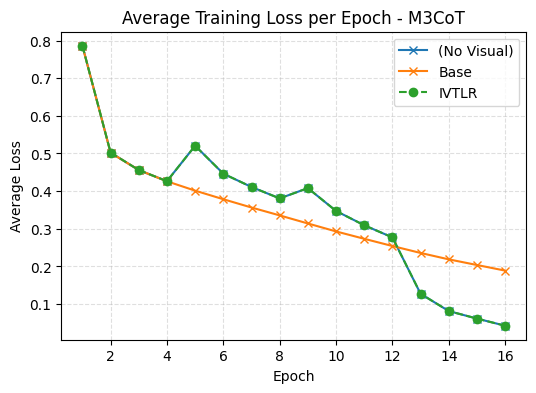

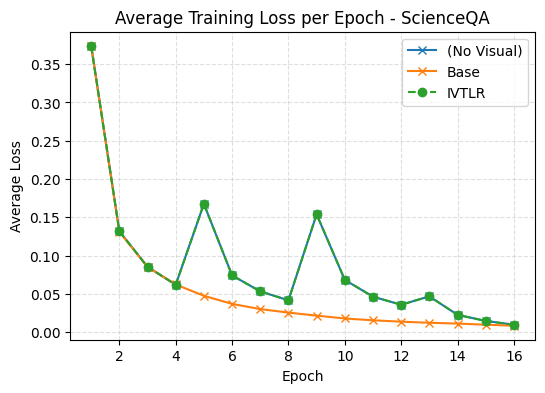

In [26]:
if not loss_df.empty:
    df = loss_df.reset_index()
    for dataset_name, dataset_df in df.groupby("dataset"):
        fig, ax = plt.subplots(figsize=(6, 4))
        for model_name, model_df in dataset_df.groupby("model"):
            model_df = model_df.sort_values("epoch")
            if model_name == "IVTLR":
                ax.plot(model_df["epoch"], model_df["avg_loss"], marker="o", label=model_name, linestyle="--")
            else:
                ax.plot(model_df["epoch"], model_df["avg_loss"], marker="x", label=model_name, linestyle="-")
        ax.set_title(f"Average Training Loss per Epoch - {dataset_name}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Average Loss")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend()
        plt.show()